In [1]:
# This dataset (online Retail from Kaggle: https://www.kaggle.com/datasets/yasserh/customer-segmentation-dataset?resource=download)
#1, Read data
import pandas as pd 
df=pd.read_excel("C:/Users/User/codveda_tasks/Task3_level2(Customer Segmentation_Kmea)/Online Retail.xlsx")


In [2]:
#2. exploring data 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
#Drop none values
df=df.dropna(subset=['Description','CustomerID'])

In [6]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [7]:
# split data and time from InvoiceDate column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceHour'] = df['InvoiceDate'].dt.hour
df['Invoiceyear'] = df['InvoiceDate'].dt.year
df['InvoiceDay'] = df['InvoiceDate'].dt.day



df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceHour,Invoiceyear,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,8,2010,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,8,2010,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,8,2010,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,8,2010,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,8,2010,1


In [8]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.month


In [9]:
# drop not usefull data
df=df.drop(['InvoiceDate', 'Description', 'StockCode'], axis=1)
df.head()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Country,InvoiceHour,Invoiceyear,InvoiceDay,InvoiceMonth
0,536365,6,2.55,17850.0,United Kingdom,8,2010,1,12
1,536365,6,3.39,17850.0,United Kingdom,8,2010,1,12
2,536365,8,2.75,17850.0,United Kingdom,8,2010,1,12
3,536365,6,3.39,17850.0,United Kingdom,8,2010,1,12
4,536365,6,3.39,17850.0,United Kingdom,8,2010,1,12


<Axes: xlabel='Invoiceyear'>

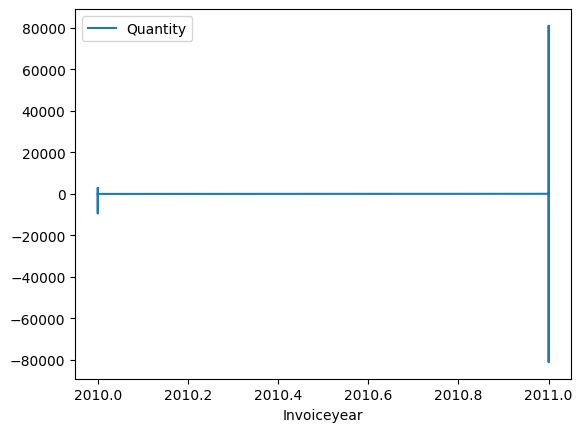

In [10]:

#exploring the relationships between years and amonunt of sells

df.plot( 'Invoiceyear' , 'Quantity' )


<Axes: xlabel='InvoiceHour'>

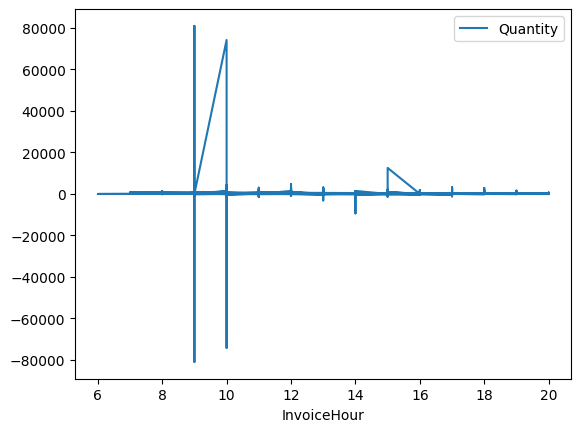

In [11]:
df.plot( 'InvoiceHour' , 'Quantity' )



<Axes: xlabel='InvoiceMonth'>

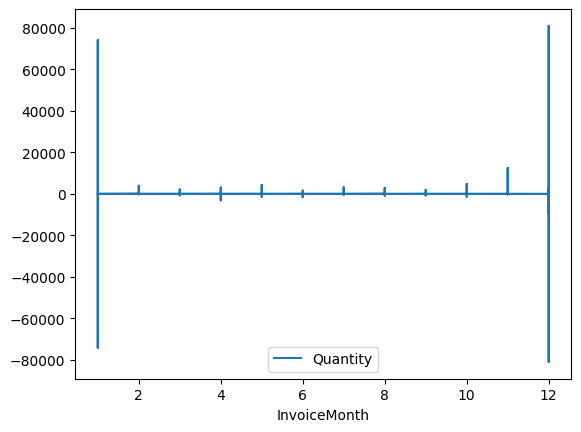

In [12]:
df.plot( 'InvoiceMonth' , 'Quantity' )


<Axes: xlabel='Country'>

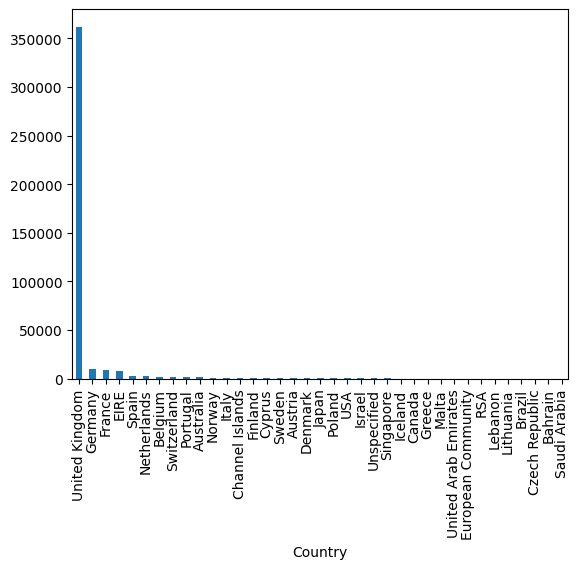

In [13]:
import matplotlib.pyplot as plt
df['Country'].value_counts().plot(kind='bar')

In [14]:
# label Encoding for country
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country_encoded'] = le.fit_transform(df['Country'])


In [16]:
df=df.drop(['Country'], axis=1)
df


,InvoiceNo,Quantity,UnitPrice,CustomerID,InvoiceHour,Invoiceyear,InvoiceDay,InvoiceMonth,Country_encoded
0,536365,6,2.55,17850.0,8,2010,1,12,35
1,536365,6,3.39,17850.0,8,2010,1,12,35
2,536365,8,2.75,17850.0,8,2010,1,12,35
3,536365,6,3.39,17850.0,8,2010,1,12,35
4,536365,6,3.39,17850.0,8,2010,1,12,35
...,...,...,...,...,...,...,...,...,...
541904,581587,12,0.85,12680.0,12,2011,9,12,13
541905,581587,6,2.10,12680.0,12,2011,9,12,13
541906,581587,4,4.15,12680.0,12,2011,9,12,13
541907,581587,4,4.15,12680.0,12,2011,9,12,13


In [20]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
scaler = StandardScaler()
X=df[['Quantity','UnitPrice','Country_encoded']]
X_scaled = scaler.fit_transform(X)

In [23]:
from sklearn.cluster import KMeans

wcss = [] # Within-Cluster Sum of Squares
#هذه قائمة فارغة سيتم تخزين قيمة Within-Cluster Sum of Squares لكل عدد من العناقيد (K).
#اختصار WCSS يعني: مجموع مربعات المسافات داخل كل عنقود.
#هدفه قياس مدى تماسك العناقيد (كلما كان أقل كان أفضل).
for i in range(1, 11): # Test K from 1 to 10
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)



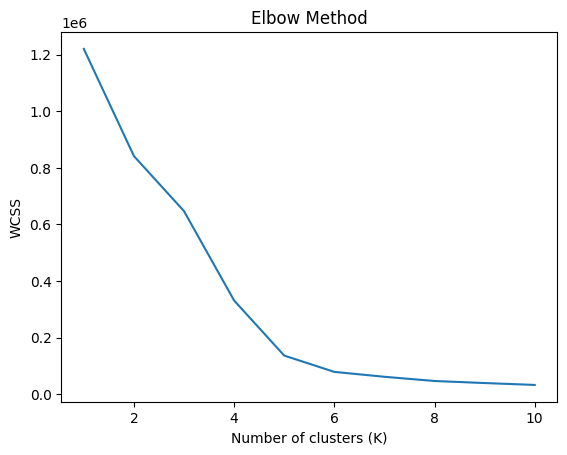

In [24]:
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [36]:
# based on previous plot we noticed that the best K=4, because there ia a small updating after it
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

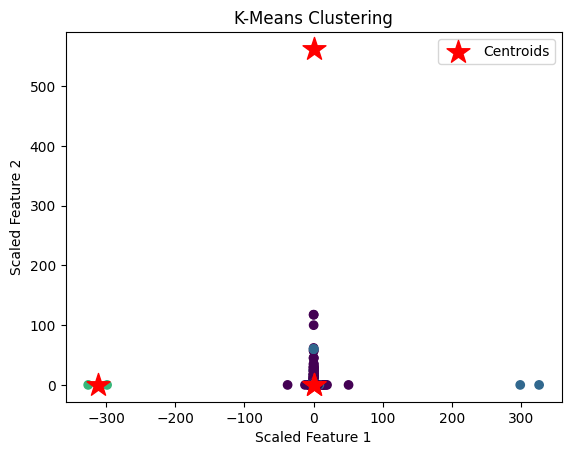

In [37]:
# Add cluster labels to the original DataFrame
df['cluster'] = kmeans.labels_

# Visualize the clusters (example with 2 features)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='*', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()


In [ ]:
# we noticed that we have 4 clusters for customers based on 'Quantity'and 'UnitPrice' features